<a href="https://colab.research.google.com/github/jonshiach/graphics-book/blob/main/Scanline_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The scanline algorithm

Jon Shiach

---

The scanline algorithm draws a polygon defined by pixel co-ordinates `X` and `Y` on the raster array `R`. See [scanline algorithm](https://jonshiach.github.io/graphics-book/jupyter-notebooks/1.3_Drawing_polygons.html#the-scanline-algorithm) for more details.

```
function drawpolygon(R, X, Y, colour)

ET := empty list
for each edge of the polygon (x0, y0) -> (x1, y1)
    if y_0 < y_1 the
        xmin := x_0, xmax := x_1, ymin := y_0 and ymax := y_1
    else if y_0 > y_1 then
       xmin := x_1, xmax := x_0, ymin := y_1 and ymax := y_0
    else
       continue to next edge
    dx := |xmin - xmax|
    dy := |ymin - ymax|
    x_{step} := sign(xmax - xmin)
    N := 0
    append (xmin, N, x_{step}, dx, dy, ymin, ymin) to ET

AET := empty list   
y := 0
while ET or AET are non-empty
    for each edge in ET 
        if ymin = y then 
            move edge from ET to AET
    sort AET by x in ascending order
    fill pixels between every pair of x co-ordinates
    for each edge in AET
        if ymax = y then
            remove edge from AET
        N := N + dx
        while N > dy do
            x := x + x_{step}
            N := N - dy             
    y := y + 1

return R
``` 

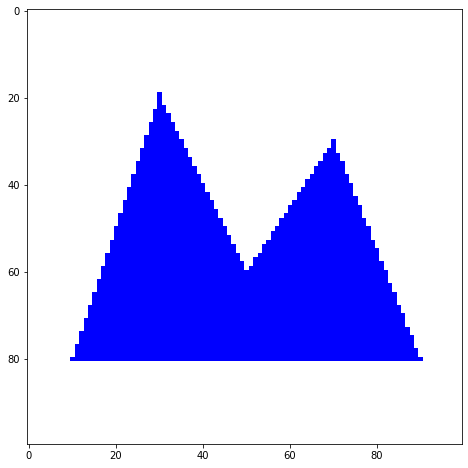

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def drawpolygon(R, X, Y, colour):

    # Generate edge table
    n = len(X)
    ET = []
    j = n - 1
    for i in range(n):
        if Y[i] < Y[j]:
            imin, imax = i, j
        elif Y[i] > Y[j]:
            imin, imax = j, i
        else:
            j = i
            continue  
                 
        dx, dy = abs(X[imin] - X[imax]), abs(Y[imin] - Y[imax])
        if X[imin] > X[imax]:
            xstep = -1
        else:
            xstep = 1
            
        edge = {'x' : X[imin], 'N' : 0, 'dx' : abs(dx), 'dy' : abs(dy), 
                'ymin' : Y[imin], 'ymax' : Y[imax], 'xstep' : xstep}
        ET.append(edge)
        j = i
        
    # Loop through scanlines
    y = min(Y)
    AET = []
    n = 1
    while len(ET) > 0 or len(AET) > 0:
        
        # Move edges from ET to AET whose ymin = y
        i = 0
        while i < len(ET):
            if ET[i]['ymin'] == y:
                AET.append(ET.pop(i))
            else:
                i += 1
        
        # Sort AET by x value
        AET = sorted(AET, key=lambda d: d['x']) 

        # Fill scanline
        i = 0
        while i < len(AET) - 1:
            R[y,AET[i]['x']:AET[i+1]['x']+1,:] = colour
            i += 2
      
        # Remove edges from AET whose ymax = y
        i = 0
        while i < len(AET):
            if AET[i]['ymax'] == y:
                AET.pop(i)
            else:
                i += 1
        
        # Update N and x
        for edge in AET:
            edge['N'] += edge['dx']
            while edge['N'] >= edge['dy']:
                edge['N'] -= edge['dy']
                edge['x'] += edge['xstep']

        y += 1       
              
    return R 


def pixelcoords(X, Y, Nx, Ny):
    X = [int(x * Nx) for x in X]
    Y = [int((1 - y) * Nx) for y in Y]
    return X, Y


# Define polygon vertices and colour
X = [0.1, 0.9, 0.7, 0.5, 0.3]
Y = [0.2, 0.2, 0.7, 0.4, 0.8]
colour = [0, 0, 255]

# Convert vertex co-ordinates to pixel coordinates
Nx, Ny = 100, 100
X, Y = pixelcoords(X, Y, Nx, Nx)

# Draw polygon
R = 255 * np.ones((Nx, Nx, 3)).astype(int)
R = drawpolygon(R, X, Y, colour)

# Plot raster
fig, ax = plt.subplots(figsize=(8,8))
plt.imshow(R)
plt.show()